# Saudi Digital Concierge — Data Exploration
## Source 3: Saudi Tourism Dataset 2015–2024 (Kaggle)

**File:** `data/raw/tourism_statistics/tourism_data.csv`
**Purpose:** tourism demand, spending, and overnight stays by province, year and tourism type.

This notebook profiles the dataset: coverage, schema, data quality (missing values,
duplicates, zero rows, granularity), summary statistics, and a few exploratory charts.
It ends with cleaning recommendations for the `cleaning` stage of the pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# Resolve the data path whether the notebook runs from notebooks/ or the repo root.
CSV = Path.cwd().parent / "data" / "raw" / "tourism_statistics" / "tourism_data.csv"
if not CSV.exists():
    CSV = Path("data") / "raw" / "tourism_statistics" / "tourism_data.csv"

df = pd.read_csv(CSV)
print("Loaded:", CSV)
print("Shape:", df.shape)
df.head()

Loaded: /home/user/saudi-Digital-Concierge/data/raw/tourism_statistics/tourism_data.csv
Shape: (1058, 9)


,YEARS,Tourists_Number,Overnight_Stay,Tourists_Spending,Avg_Stay,Avg_Spending_Trip,Avg_Spending_Night,Province,Tourism_Type
0,2015,6.0,59.0,43.0,10.0,7029.0,727.0,Albaha,Inbound
1,2015,6.0,59.0,43.0,10.0,7029.0,727.0,Albaha,Inbound
2,2015,0.0,0.0,0.0,0.0,0.0,0.0,Albaha,Inbound
3,2015,0.0,0.0,0.0,0.0,0.0,0.0,Albaha,Inbound
4,2015,1041.0,8807.0,1120.0,8.5,1075.0,127.0,Albaha,Domestic


## 1. Schema & column dictionary

| Column | Type | Meaning |
| ------ | ---- | ------- |
| `YEARS` | int | Year of observation (2015–2024) |
| `Tourists_Number` | float | Number of tourists (thousands) |
| `Overnight_Stay` | float | Total overnight stays (thousands of nights) |
| `Tourists_Spending` | float | Total spending (millions SAR) |
| `Avg_Stay` | float | Average length of stay (nights) |
| `Avg_Spending_Trip` | float | Average spending per trip (SAR) |
| `Avg_Spending_Night` | float | Average spending per night (SAR) |
| `Province` | str | One of 13 Saudi administrative regions |
| `Tourism_Type` | str | `Domestic` or `Inbound` |

> Unit labels are inferred from the value scales; confirm against the Kaggle source page.

In [2]:
df.info()
df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 1058 entries, 0 to 1057
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   YEARS               1058 non-null   int64  
 1   Tourists_Number     1058 non-null   float64
 2   Overnight_Stay      1058 non-null   float64
 3   Tourists_Spending   1058 non-null   float64
 4   Avg_Stay            1058 non-null   float64
 5   Avg_Spending_Trip   1058 non-null   float64
 6   Avg_Spending_Night  1058 non-null   float64
 7   Province            1058 non-null   str    
 8   Tourism_Type        1058 non-null   str    
dtypes: float64(6), int64(1), str(2)
memory usage: 74.5 KB


YEARS                   int64
Tourists_Number       float64
Overnight_Stay        float64
Tourists_Spending     float64
Avg_Stay              float64
Avg_Spending_Trip     float64
Avg_Spending_Night    float64
Province                  str
Tourism_Type              str
dtype: object

## 2. Coverage — years, provinces, tourism type

In [3]:
print("Years:", sorted(df['YEARS'].unique()))
print("\nProvinces (%d):" % df['Province'].nunique())
print(sorted(df['Province'].unique()))
print("\nTourism_Type counts:")
print(df['Tourism_Type'].value_counts())
print("\nRows per year:")
print(df['YEARS'].value_counts().sort_index())

Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Provinces (13):
['Albaha', 'Alqassim', 'Aseer', 'Eastern_region', 'Hail', 'Jazan', 'Jouf', 'Madinah', 'Makkah', 'Najran', 'Northern_borders', 'Riyadh', 'Tabuk']

Tourism_Type counts:
Tourism_Type
Domestic    540
Inbound     518
Name: count, dtype: int64

Rows per year:
YEARS
2015    106
2016    106
2017    101
2018    106
2019    107
2020    105
2021    106
2022    106
2023    107
2024    108
Name: count, dtype: int64


## 3. Data quality

Three issues to flag for cleaning:

1. **Exact duplicate rows.**
2. **Zero-valued rows** — likely missing/suppressed data encoded as `0`.
3. **Granularity** — there is *not* one row per (year, province, type); groups have
   2–6 rows, suggesting a sub-category dimension was flattened or the source stacked
   multiple observations. This must be resolved before aggregation.

In [4]:
num_cols = ['Tourists_Number','Overnight_Stay','Tourists_Spending',
            'Avg_Stay','Avg_Spending_Trip','Avg_Spending_Night']

print("Missing values per column:")
print(df.isna().sum())

print("\nExact duplicate rows:", df.duplicated().sum())

all_zero = (df[num_cols].sum(axis=1) == 0).sum()
print("All-zero metric rows:", all_zero)
print("Rows with Tourists_Number == 0:", (df['Tourists_Number'] == 0).sum())

Missing values per column:
YEARS                 0
Tourists_Number       0
Overnight_Stay        0
Tourists_Spending     0
Avg_Stay              0
Avg_Spending_Trip     0
Avg_Spending_Night    0
Province              0
Tourism_Type          0
dtype: int64

Exact duplicate rows: 28
All-zero metric rows: 20
Rows with Tourists_Number == 0: 21


In [5]:
# Granularity: how many rows exist per (year, province, type)?
group_sizes = df.groupby(['YEARS','Province','Tourism_Type']).size()
print("Distribution of rows per (year, province, type) group:")
print(group_sizes.value_counts().sort_index())

print("\nExample — Albaha, 2015 (note repeated & zero rows):")
df[(df['Province']=='Albaha') & (df['YEARS']==2015)]

Distribution of rows per (year, province, type) group:
2     9
3    89
4    64
5    65
6    32
Name: count, dtype: int64

Example — Albaha, 2015 (note repeated & zero rows):


,YEARS,Tourists_Number,Overnight_Stay,Tourists_Spending,Avg_Stay,Avg_Spending_Trip,Avg_Spending_Night,Province,Tourism_Type
0,2015,6.0,59.0,43.0,10.0,7029.0,727.0,Albaha,Inbound
1,2015,6.0,59.0,43.0,10.0,7029.0,727.0,Albaha,Inbound
2,2015,0.0,0.0,0.0,0.0,0.0,0.0,Albaha,Inbound
3,2015,0.0,0.0,0.0,0.0,0.0,0.0,Albaha,Inbound
4,2015,1041.0,8807.0,1120.0,8.5,1075.0,127.0,Albaha,Domestic
5,2015,947.0,7909.0,1016.0,8.4,1073.0,128.0,Albaha,Domestic
6,2015,33.0,269.0,39.0,8.3,1210.0,146.0,Albaha,Domestic
7,2015,62.4,629.1,65.0,10.1,1037.0,103.0,Albaha,Domestic


## 4. Summary statistics

In [6]:
df[num_cols].describe().round(1)

,Tourists_Number,Overnight_Stay,Tourists_Spending,Avg_Stay,Avg_Spending_Trip,Avg_Spending_Night
count,1058.0,1058.0,1058.0,1058.0,1058.0,1058.0
mean,1470.1,10752.6,3415.7,8.7,2441.3,351.4
std,3107.4,32095.8,12359.9,9.2,2343.4,288.3
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,29.0,186.5,63.0,4.3,1075.2,170.0
50%,269.5,1662.0,382.5,6.1,1595.5,241.5
75%,1265.0,8896.2,1871.8,8.7,3062.8,441.0
max,23487.0,430796.0,140770.0,71.0,39009.0,1987.0


## 5. Exploratory charts

For trend charts we **drop exact duplicates** and **sum** the (thousands of) tourists
per year and type. This is a first-pass view; the granularity issue above means totals
should be treated as indicative until the sub-category dimension is understood.

In [7]:
clean = df.drop_duplicates().copy()
print("Rows after dropping exact duplicates:", len(clean), "(was", len(df), ")")

yearly = (clean.groupby(['YEARS','Tourism_Type'])['Tourists_Number']
                .sum().unstack())
yearly.round(1)

Rows after dropping exact duplicates: 1030 (was 1058 )


Tourism_Type,Domestic,Inbound
YEARS,,
2015,92903.3,35982.0
2016,90072.9,36786.0
2017,87638.0,32826.8
2018,86511.0,31091.1
2019,95612.0,35519.4
2020,84214.3,8457.0
2021,127667.0,9296.3
2022,155676.0,53298.1
2023,163841.0,74045.0


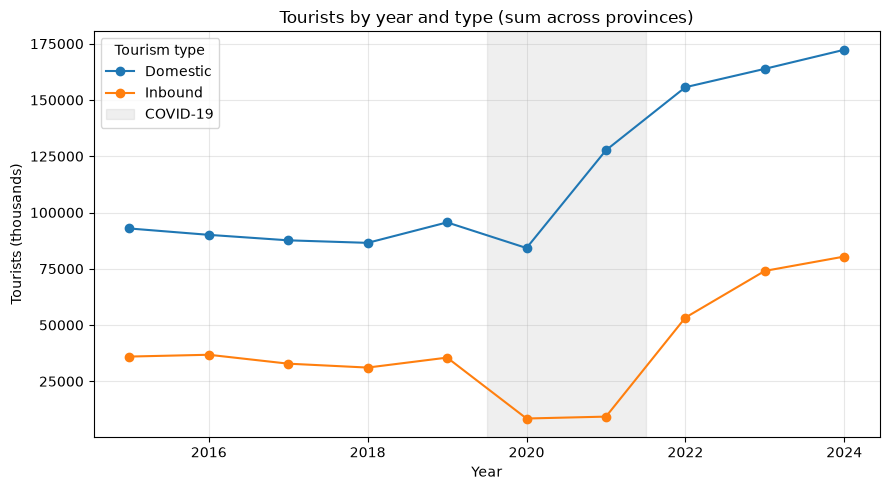

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
yearly.plot(marker='o', ax=ax)
ax.set_title("Tourists by year and type (sum across provinces)")
ax.set_ylabel("Tourists (thousands)")
ax.set_xlabel("Year")
ax.axvspan(2019.5, 2021.5, color='grey', alpha=0.12, label='COVID-19')
ax.legend(title="Tourism type")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

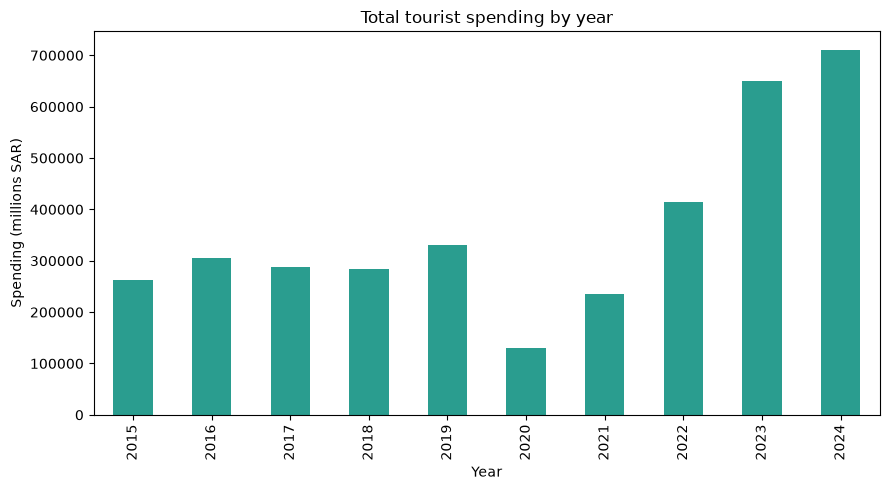

In [9]:
# Total spending per year (millions SAR)
spend = clean.groupby('YEARS')['Tourists_Spending'].sum()
fig, ax = plt.subplots(figsize=(9, 5))
spend.plot(kind='bar', ax=ax, color='#2a9d8f')
ax.set_title("Total tourist spending by year")
ax.set_ylabel("Spending (millions SAR)")
ax.set_xlabel("Year")
plt.tight_layout()
plt.show()

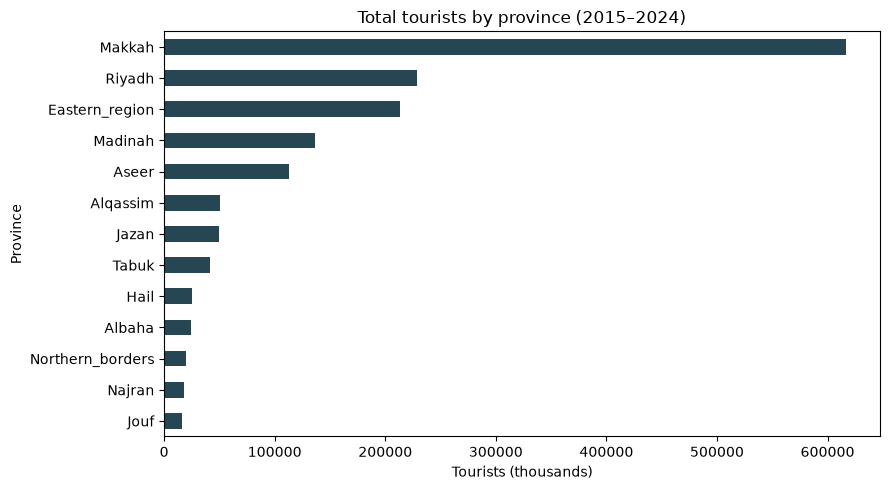

Province
Makkah              616608.9
Riyadh              229132.5
Eastern_region      213412.5
Madinah             136439.6
Aseer               112690.6
Alqassim             50944.7
Jazan                49524.0
Tabuk                41738.2
Hail                 25465.4
Albaha               23887.9
Northern_borders     20074.7
Najran               18215.9
Jouf                 16037.3
Name: Tourists_Number, dtype: float64

In [10]:
# Top provinces by total tourists (all years, both types)
by_prov = (clean.groupby('Province')['Tourists_Number'].sum()
                 .sort_values(ascending=False))
fig, ax = plt.subplots(figsize=(9, 5))
by_prov.plot(kind='barh', ax=ax, color='#264653')
ax.invert_yaxis()
ax.set_title("Total tourists by province (2015–2024)")
ax.set_xlabel("Tourists (thousands)")
plt.tight_layout()
plt.show()
by_prov.round(1)

## 6. Findings & cleaning recommendations

**Coverage**
- 10 years (2015–2024), 13 provinces, two tourism types (Domestic / Inbound).

**Signal**
- Clear COVID-19 shock: inbound tourists collapse in 2020–2021 and recover strongly
  through 2022–2024; domestic tourism grows steadily and overtakes pre-pandemic levels.

**Data quality — to handle in `src/cleaning`**
1. **Drop exact duplicate rows** (~28).
2. **Decide on zero rows** — ~20 all-zero rows likely mean "no data"; treat as `NaN`
   rather than real zeros so they don't deflate averages.
3. **Resolve granularity** — there are 2–6 rows per (year, province, type). Confirm the
   missing sub-category against the source; if none exists, aggregate deterministically
   (sum the volume columns; recompute the `Avg_*` columns from the summed totals rather
   than averaging pre-computed averages).
4. **Standardise labels** — e.g. `Eastern_region`, `Northern_borders` → human-readable
   names for retrieval; keep a canonical province key.
5. **Confirm units** (thousands of tourists / nights, millions SAR) from the Kaggle page
   and record them in the schema.

**Next step:** write `tourism_statistics` cleaning to `data/processed/` producing one
tidy row per (year, province, type) with documented units.